<a href="https://colab.research.google.com/github/giovanis11/BigData/blob/main/notebooks/colab-github-demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
#Part A
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [5]:
df = pd.read_csv("perceptron_dataset.csv", encoding="latin1")
df.head()

,x1,x2,label
0,1.116098,0.231663,1
1,1.458366,0.842998,1
2,1.840974,-1.590146,1
3,0.983873,2.091646,1
4,0.362833,-1.408353,0


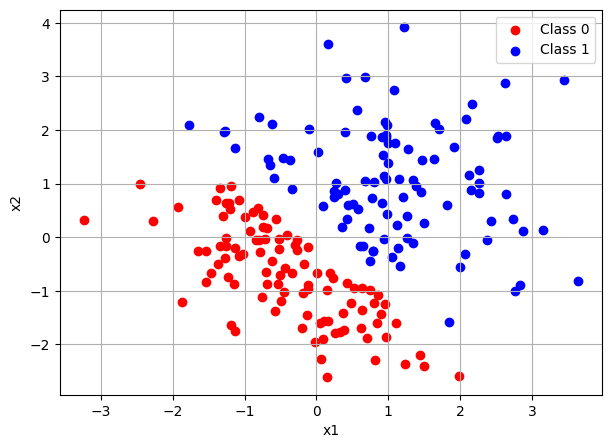

In [14]:
plt.figure(figsize=(7,5))
plt.scatter(
    df[df["label"] == 0]["x1"],
    df[df["label"] == 0]["x2"],
    color="red",
    label="Class 0"
)
plt.scatter(
    df[df["label"] == 1]["x1"],
    df[df["label"] == 1]["x2"],
    color="blue",
    label="Class 1"
)
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid()
plt.show()


In [17]:
class0center = df[df["label"]== 0].mean()
print(class0center)
class1center = df[df["label"]== 1].mean()
print(class1center)


x1      -0.406741
x2      -0.724834
label    0.000000
dtype: float64
x1       1.072999
x2       1.072211
label    1.000000
dtype: float64


In [23]:
w = class1center - class0center
print(w)


x1       1.479741
x2       1.797045
label    1.000000
dtype: float64


In [20]:
midpoint_x1 = (class0center["x1"] + class1center["x1"]) / 2
midpoint_x2 = (class0center["x2"] + class1center["x2"]) / 2
print(midpoint_x1, midpoint_x2)

0.3331288527755696 0.173688441602309


In [29]:
b = -np.dot(w, [midpoint_x1, midpoint_x2])
print(b)

-0.8056698969919992


In [ ]:
# PART B

In [30]:
learning_rate = 0.01
max_epochs = 100

In [38]:
X = df[["x1", "x2"]].values
y = df[["label"]].values

y = np.where(y == 0, -1, 1)
w_initial = np.array([1.48, 1.80])
b_initial = -0.81

def train(stop_zero = True):
  w = w_initial.copy()
  b = b_initial

  start_time = time.time()

  for epoch in range(max_epochs):
        mistakes = 0
        for i in range(len(X)):
          score = np.dot(w, X[i]) + b
          prediction = 1 if score >= 0 else -1
          if prediction != y[i]:
            mistakes += 1
            w += learning_rate * y[i] * X[i]
            b += learning_rate * y[i]
        if stop_zero and mistakes == 0:
          break
  end_time = time.time()
  final_predictions = np.where(np.dot(X, w) + b >= 0, 1, -1)
  misclass = np.sum(final_predictions !=y)
  accuracy = 1 - misclass / len(y)
